In [1]:
import sys
!{sys.executable} -m pip install cupy-cuda12x

In [2]:
import time
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# CPU
def vector_sum_cpu(vector):
    start = time.time()
    total = 0.0

    for value in vector:
        total += value

    end = time.time()
    return total, end - start

In [4]:
# GPU
def vector_sum_gpu(vector):
    # Конверттация в float32
    vector = vector.astype(np.float32)

    # Перенос на GPU
    vector_device = cp.asarray(vector)

    # Синхронизация для точного замера времени
    cp.cuda.Stream.null.synchronize()
    start = time.time()

    # Суммирование на GPU
    result_device = cp.sum(vector_device)

    # Синхронизация после вычислений
    cp.cuda.Stream.null.synchronize()
    end = time.time()

    # Возврат результата на CPU
    result = cp.asnumpy(result_device)

    return float(result), end - start

In [5]:
def gen_vector(n):
    return np.random.rand(n).astype(np.float32)


def correct(sum_cpu, sum_gpu):
    return np.isclose(sum_cpu, sum_gpu, rtol=1e-3, atol=1e-5)

--------------------------------------------------
Vector Size    CPU (sec)      GPU (sec)      Speedup        
--------------------------------------------------
1000           0.000043       0.000354       0.12           
10000          0.000397       0.000095       4.17           
50000          0.001861       0.000101       18.49          
100000         0.003701       0.000091       40.74          
500000         0.018818       0.000115       164.10         
1000000        0.038205       0.000134       285.13         
13             0.000004       0.000017       0.24           
2              0.000001       0.000012       0.10           
3              0.000001       0.000011       0.10           
0              0.000001       0.000011       0.07           
10010          0.000375       0.000016       23.83          
--------------------------------------------------

Среднее ускорение: 48.83x
Максимальное ускорение: 285.13x
Минимальное ускорение: 0.07x


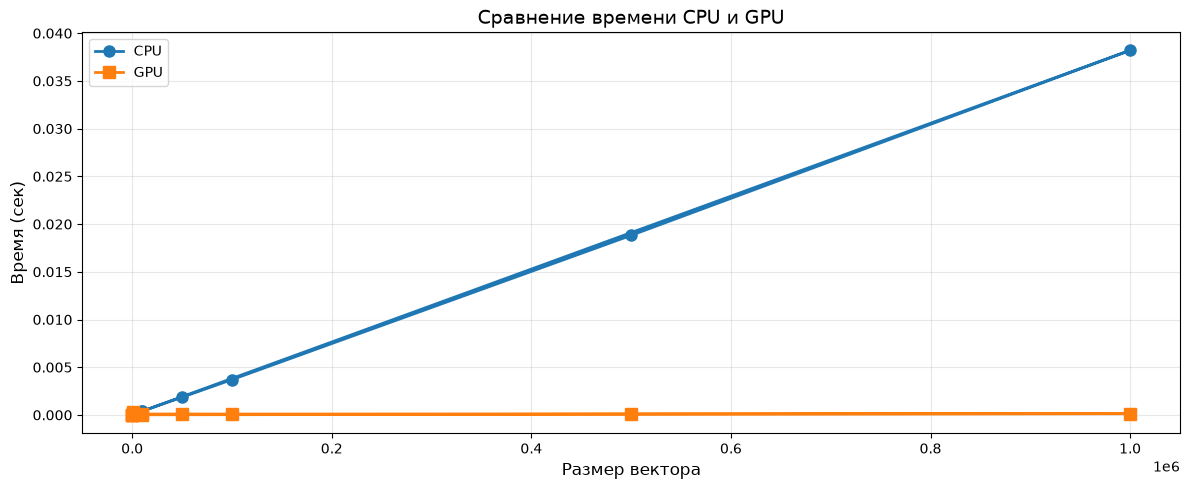

In [11]:
sizes = [1000, 10000, 50000, 100000, 500000, 1000000, 10^7, 10^8, 10^9, 10^10,10^10000]

cpu_times = []
gpu_times = []
speedups = []

print("-" * 50)
print(f"{'Vector Size':<15}{'CPU (sec)':<15}{'GPU (sec)':<15}{'Speedup':<15}")
print("-" * 50)

for n in sizes:
    vector = gen_vector(n)

    sum_cpu, t_cpu = vector_sum_cpu(vector)
    sum_gpu, t_gpu = vector_sum_gpu(vector)

    correct_check =  correct(sum_cpu, sum_gpu)

    speedup = t_cpu / t_gpu if t_gpu > 0 else 0

    cpu_times.append(t_cpu)
    gpu_times.append(t_gpu)
    speedups.append(speedup)

    print(f"{n:<15}{t_cpu:<15.6f}{t_gpu:<15.6f}{speedup:<15.2f}")

print("-" * 50)

avg_speedup = sum(speedups) / len(speedups)
print(f"\nСреднее ускорение: {avg_speedup:.2f}x")
print(f"Максимальное ускорение: {max(speedups):.2f}x")
print(f"Минимальное ускорение: {min(speedups):.2f}x")

plt.figure(figsize=(12, 5))

plt.plot(sizes, cpu_times, marker='o', label='CPU', linewidth=2, markersize=8)
plt.plot(sizes, gpu_times, marker='s', label='GPU', linewidth=2, markersize=8)
plt.xlabel("Размер вектора", fontsize=12)
plt.ylabel("Время (сек)", fontsize=12)
plt.title("Сравнение времени CPU и GPU", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("vector_sum_cpu_gpu.png", dpi=300, bbox_inches='tight')
plt.show()